# Notebook 5 — Evaluation & Comparison

Evaluate all models on the test set and compare performance via metrics, confusion matrices, ROC curves, and feature importance.

## Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)

## Load Data & Models

In [2]:
import joblib

X_train_scaled = pd.read_csv('X_train_scaled.csv')
X_test_scaled  = pd.read_csv('X_test_scaled.csv')
y_test         = pd.read_csv('y_test.csv').squeeze()
y_train        = pd.read_csv('y_train.csv').squeeze()

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
models = {}
for name in model_names:
    fname = name.lower().replace(' ', '_') + '.pkl'
    models[name] = joblib.load(fname)

log_reg = models['Logistic Regression']
rf      = models['Random Forest']
xgb     = models['XGBoost']

feature_columns = joblib.load('feature_columns.pkl')

RANDOM_STATE = 42
print('Models loaded:', list(models.keys()))

Models loaded: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


## 6. Model Evaluation

> **Note:** because attrition is the *minority* class (~16%), **Recall and F1 for the "Yes" class matter more than raw Accuracy**.

In [3]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df.sort_values('F1-Score', ascending=False)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.755,0.356,0.660,0.463,0.804
XGBoost,0.830,0.462,0.383,0.419,0.771
Decision Tree,0.762,0.342,0.532,0.417,0.635
Random Forest,0.830,0.421,0.170,0.242,0.770


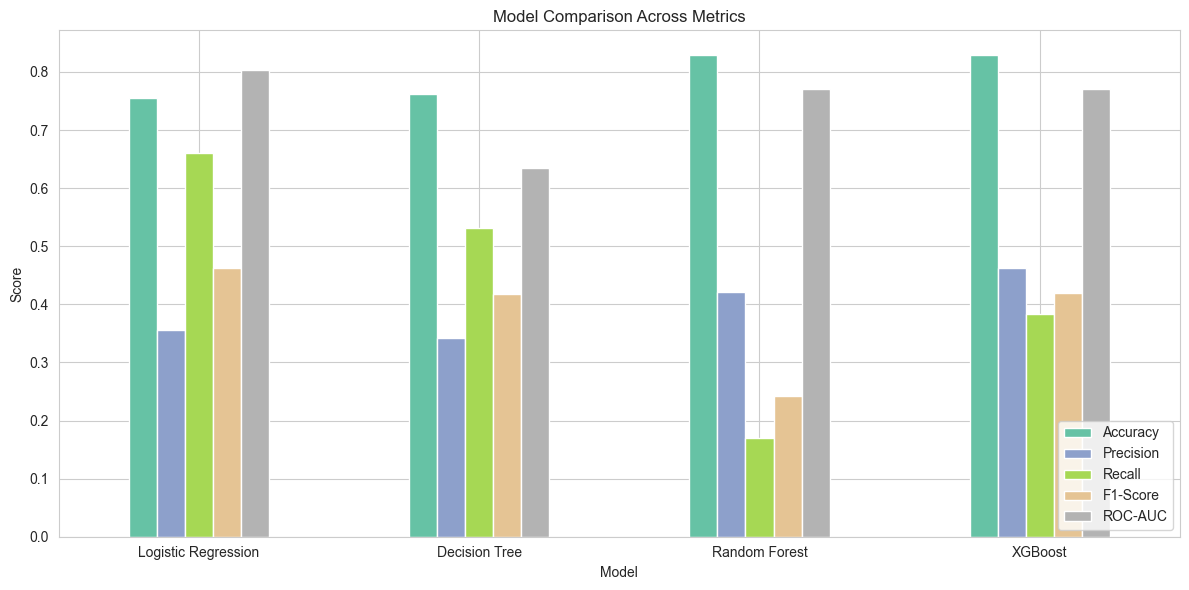

In [4]:
results_df.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


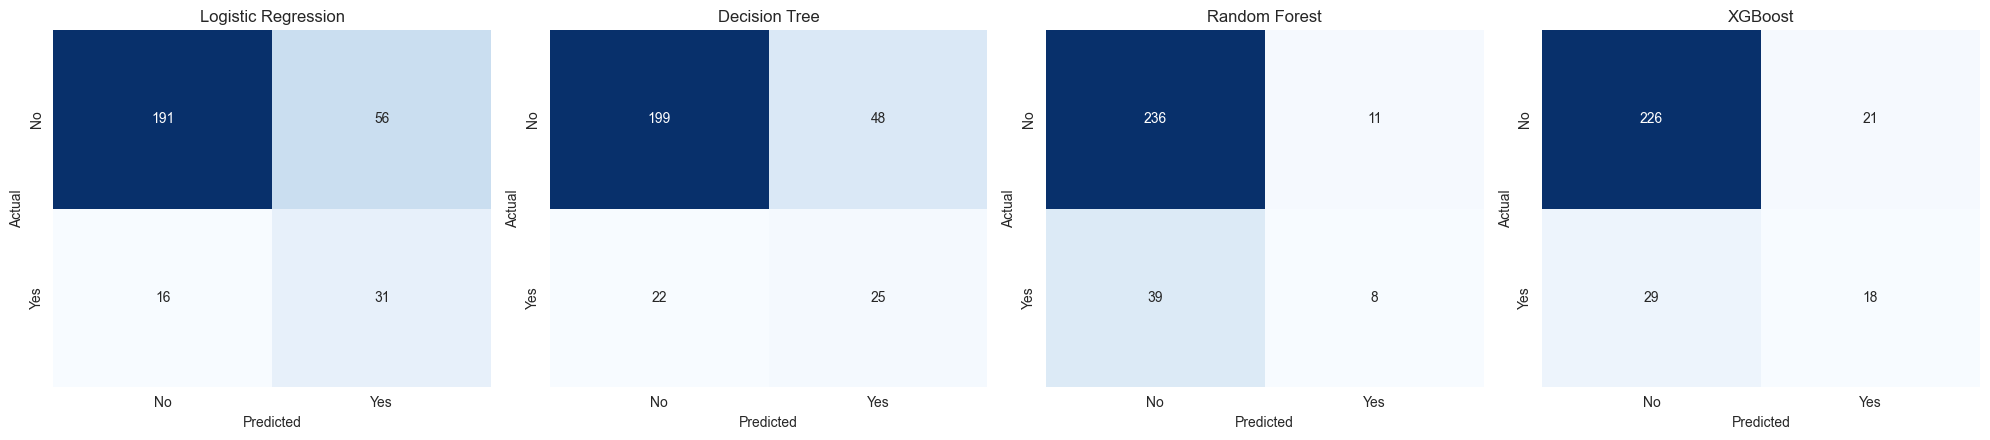

In [5]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


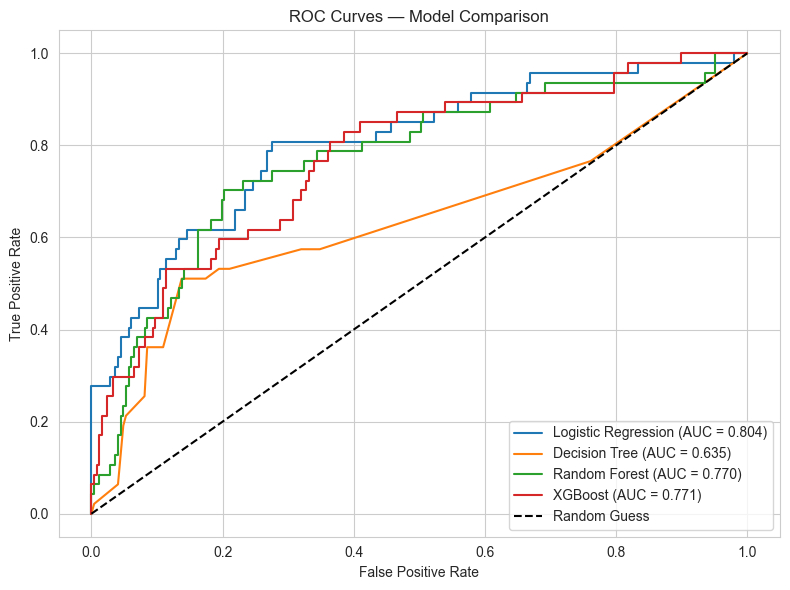

In [6]:
# ROC curves for all models
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [7]:
# Detailed classification report for the best model (by F1-score)
best_model_name = results_df['F1-Score'].idxmax()
best_model = models[best_model_name]
print(f"Best model by F1-Score: {best_model_name}\n")
print(classification_report(y_test, best_model.predict(X_test_scaled), target_names=['No', 'Yes']))


Best model by F1-Score: Logistic Regression

              precision    recall  f1-score   support

          No       0.92      0.77      0.84       247
         Yes       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



## 7. Feature Importance

NameError: name 'X_train' is not defined

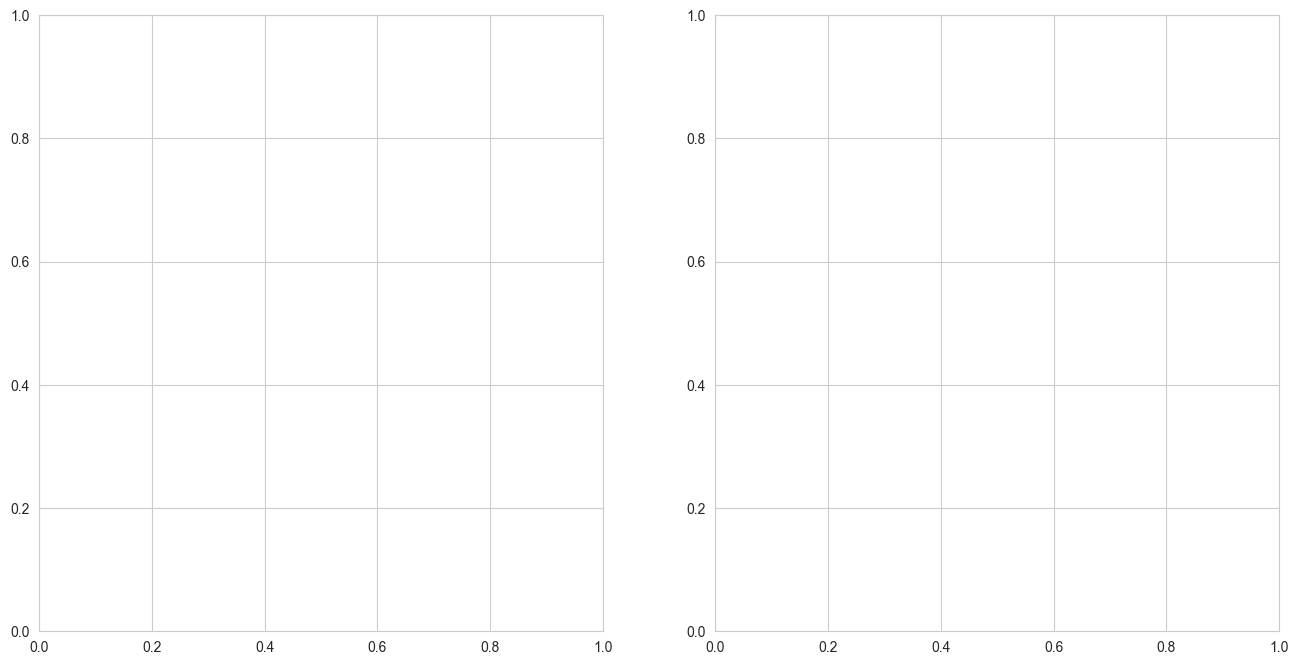

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Random Forest importance
rf_importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
sns.barplot(x=rf_importance.values, y=rf_importance.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 15 Features — Random Forest')
axes[0].set_xlabel('Importance')

# XGBoost importance
xgb_importance = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
sns.barplot(x=xgb_importance.values, y=xgb_importance.index, ax=axes[1], palette='magma')
axes[1].set_title('Top 15 Features — XGBoost')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()


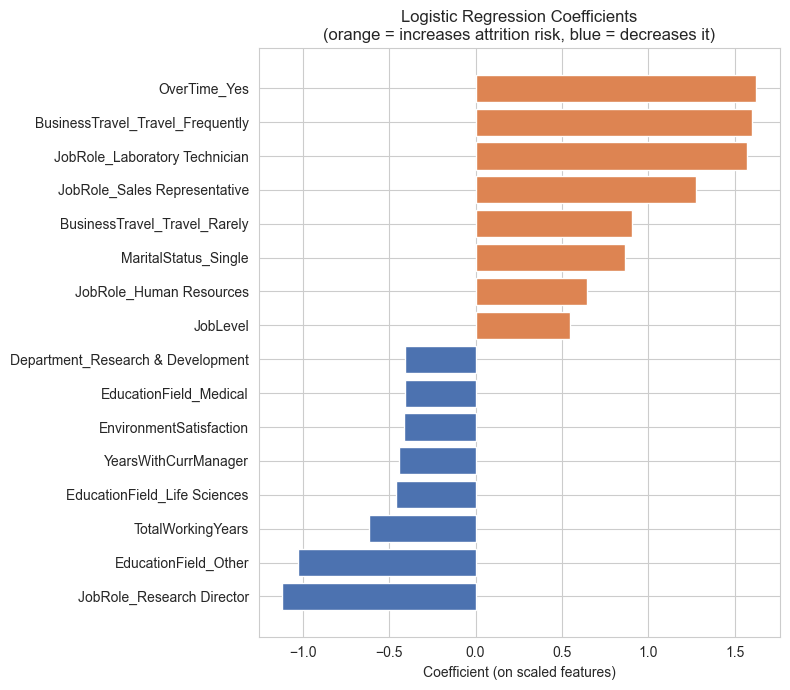

In [ ]:
# Logistic Regression coefficients (signed — shows direction of effect)
coef = pd.Series(log_reg.coef_[0], index=X_train.columns).sort_values()
top_bottom = pd.concat([coef.head(8), coef.tail(8)])

plt.figure(figsize=(8, 7))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in top_bottom.values]
plt.barh(top_bottom.index, top_bottom.values, color=colors)
plt.title('Logistic Regression Coefficients\n(orange = increases attrition risk, blue = decreases it)')
plt.xlabel('Coefficient (on scaled features)')
plt.tight_layout()
plt.show()


## Save Best Model Name

In [ ]:
import joblib

best_model_name = results_df['F1-Score'].idxmax()
best_model = models[best_model_name]

joblib.dump(best_model, 'best_attrition_model.pkl')
print(f'Best model: {best_model_name} — saved as best_attrition_model.pkl')